# Simulation Design: Controlled Experiments with Covariates

When benchmarking analysis methods or training ML models, you often need **controlled experiments** with known sources of variation. PointillSim's design module lets you:

1. Define **covariates** that vary across samples
2. Control which **effects** are active
3. Generate complete **experimental designs**
4. Track the **design matrix** for downstream analysis

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

np.random.seed(42)

from pointillsim import (
    TissueCellTypes,
    CellTypesProperties,
    HybISS_Setup,
    FOVDistribution,
    FrameWideElement,
    VacuolatedStructure,
    RandomCellTypeRule,
    MixOfNCellTypesRule,
    DistanceBasedRule,
)

# Import design module
from pointillsim.design import (
    Covariate,
    CovariateSystem,
    EffectController,
    SimulationDesign,
    DesignMatrix,
)

# Import covariate-based rules
from pointillsim.rules import (
    CovariateBasedRule,
    ThresholdCovariateRule,
    SpatialCovariateRule,
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
plt.style.use('seaborn-v0_8-whitegrid')

---
## 1. Defining Covariates

A **covariate** is any variable that varies across samples and may influence the simulation. Covariates can be:

- **Continuous**: Age, distance from landmark, expression level
- **Categorical**: Treatment group, tissue region, batch ID

In [2]:
# Create individual covariates

# Continuous covariate: disease severity (0-1 scale)
severity = Covariate(
    name='severity',
    covariate_type='continuous',
    values=[0.0, 1.0],  # [min, max] range
    description='Disease severity score (0=healthy, 1=severe)'
)

# Categorical covariate: treatment group
treatment = Covariate(
    name='treatment',
    covariate_type='categorical',
    values=['control', 'drug_A', 'drug_B'],  # list of categories
    description='Treatment condition'
)

# Continuous covariate: cell density
density = Covariate(
    name='cell_density',
    covariate_type='continuous',
    values=[0.5, 2.0],  # [min, max] range
    description='Relative cell density multiplier'
)

print("Defined covariates:")
for cov in [severity, treatment, density]:
    print(f"  {cov}")

Defined covariates:
  Covariate(name='severity', covariate_type='continuous', values=[0.0, 1.0], description='Disease severity score (0=healthy, 1=severe)', default=None)
  Covariate(name='treatment', covariate_type='categorical', values=['control', 'drug_A', 'drug_B'], description='Treatment condition', default=None)
  Covariate(name='cell_density', covariate_type='continuous', values=[0.5, 2.0], description='Relative cell density multiplier', default=None)


In [3]:
# Create a covariate system
cov_system = CovariateSystem()
cov_system.add_covariate(severity)
cov_system.add_covariate(treatment)
cov_system.add_covariate(density)

print(f"CovariateSystem with {len(cov_system.covariates)} covariates:")
for name, cov in cov_system.covariates.items():
    print(f"  {name}: {cov.covariate_type}")

CovariateSystem with 3 covariates:
  severity: continuous
  treatment: categorical
  cell_density: continuous


In [4]:
# Sample from the covariate system
# Generate random covariate configurations

n_samples = 10
samples = []

for i in range(n_samples):
    sample = cov_system.sample_configuration()
    samples.append(sample)

print(f"Sampled {n_samples} covariate combinations:")
import pandas as pd
samples_df = pd.DataFrame(samples)
print(samples_df)

Sampled 10 covariate combinations:
   severity treatment  cell_density
0  0.475294    drug_B      1.333490
1  0.708681    drug_A      0.523231
2  0.874636   control      1.757326
3  0.297473    drug_A      1.465098
4  0.287116   control      1.213120
5  0.483900   control      1.050804
6  0.054930    drug_B      1.948386
7  0.323504    drug_A      1.672325
8  0.177904    drug_B      1.886648
9  0.174016    drug_B      0.548817


---
## 2. Covariate-Based Cell Type Rules

Use covariates to control cell type distributions within FOVs.

In [5]:
# Setup for demonstrations
n_cell_types = 4
frame_size = 500

tissue = TissueCellTypes()
tissue.generate_types_and_markers(
    n_genes=30,
    n_cell_types=n_cell_types,
)
tissue._cell_type_names = ['Healthy', 'Stressed', 'Immune', 'Fibroblast']

cell_props = CellTypesProperties(n_cell_types=n_cell_types)

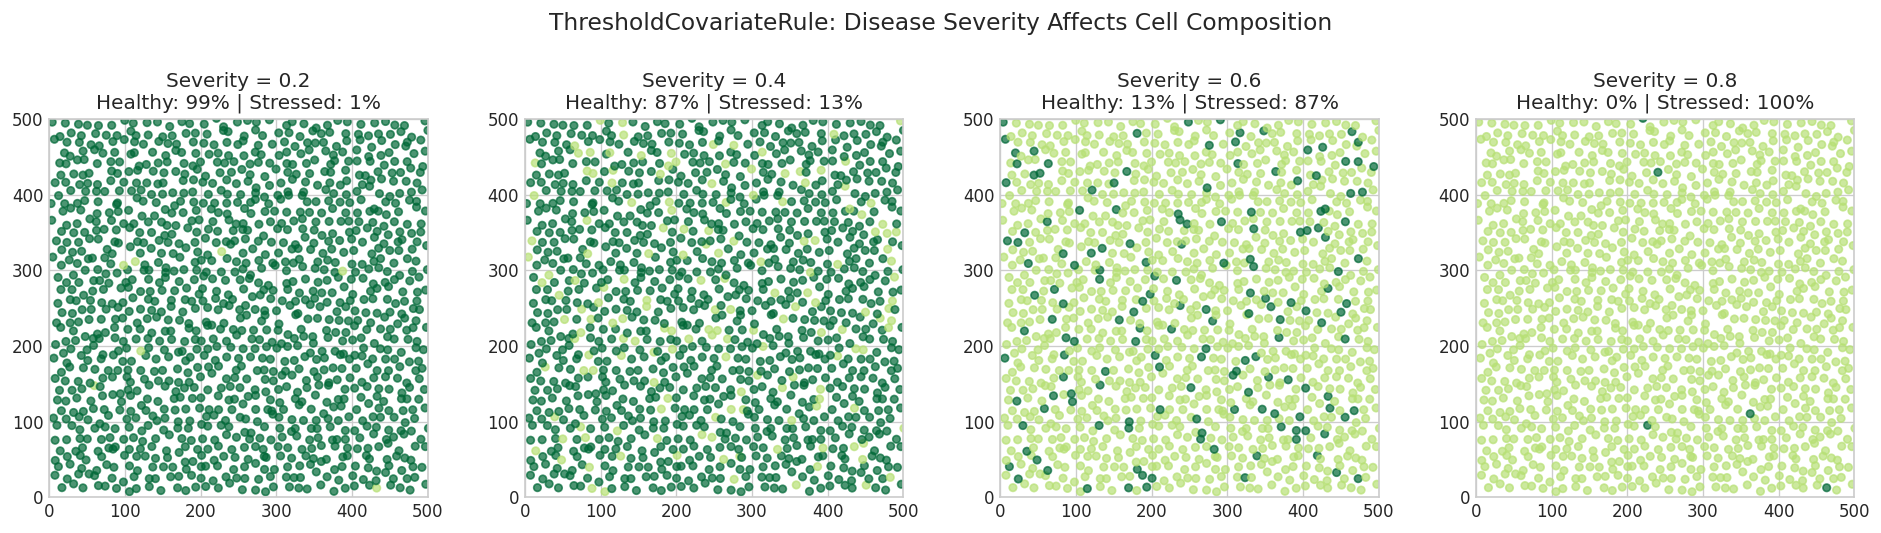

In [6]:
# ThresholdCovariateRule: Step-like change at threshold
# When severity > 0.5, switch from healthy (type 0) to stressed (type 1)

from pointillsim.rules import ThresholdCovariateRule

# Need to provide a covariate_getter function that extracts severity from element
# For this demo, we'll create a simple function that returns a constant severity

def create_threshold_fov(severity_value):
    '''Generate FOV with specific severity value'''
    
    # Create covariate getter that returns the severity value for all cells
    def severity_getter(cell_centroids):
        import numpy as np
        return np.full(len(cell_centroids), severity_value)
    
    threshold_rule = ThresholdCovariateRule(
        n_cell_types=n_cell_types,
        covariate_name='severity',
        thresholds=[0.5],  # List of threshold values
        type_indices=[0, 1],  # Types: [below threshold, above threshold]
        covariate_getter=severity_getter,
        transition_width=0.1,  # Smooth transition around threshold
    )
    
    fov_dist = FOVDistribution(
        frame_size=frame_size,
        background_element=lambda: FrameWideElement(
            frame_size=frame_size,
            tipical_cell_spacing=15,
            rules=threshold_rule,
        ),
    )
    
    return fov_dist.generate_fov()

# Visualize the threshold rule
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

severities = [0.2, 0.4, 0.6, 0.8]

for ax, sev in zip(axes, severities):
    np.random.seed(42)
    fov = create_threshold_fov(sev)
    
    ax.scatter(fov.cell_centroids[:, 0], fov.cell_centroids[:, 1],
               c=fov.class_instance, cmap='RdYlGn_r', vmin=0, vmax=n_cell_types-1,
               s=20, alpha=0.7)
    ax.set_xlim(0, frame_size)
    ax.set_ylim(0, frame_size)
    ax.set_aspect('equal')
    
    # Count proportions
    counts = Counter(fov.class_instance)
    healthy_pct = 100 * counts.get(0, 0) / fov.n_cells if fov.n_cells > 0 else 0
    stressed_pct = 100 * counts.get(1, 0) / fov.n_cells if fov.n_cells > 0 else 0
    
    ax.set_title(f'Severity = {sev}\nHealthy: {healthy_pct:.0f}% | Stressed: {stressed_pct:.0f}%')

plt.suptitle('ThresholdCovariateRule: Disease Severity Affects Cell Composition', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

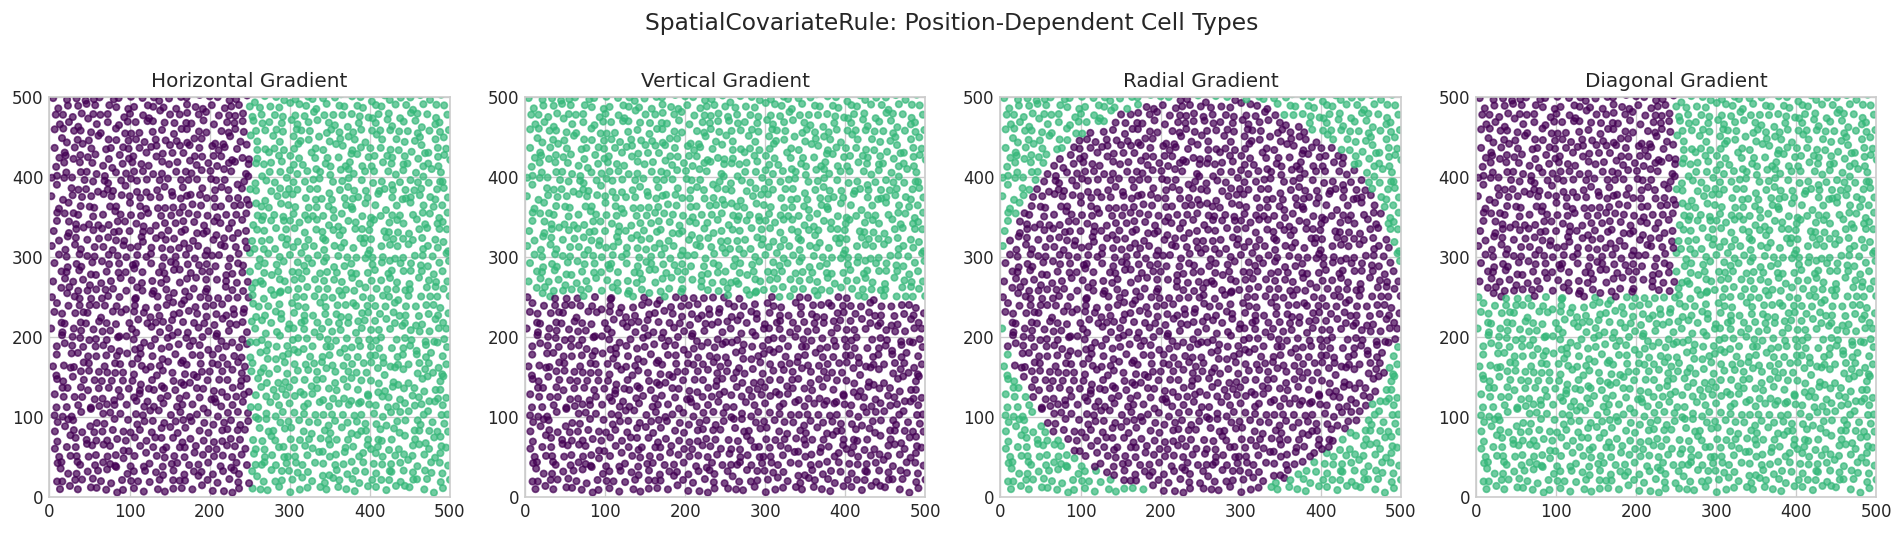

In [12]:
# SpatialCovariateRule: Cell types vary with position
# Creates spatial gradients within FOVs

from pointillsim.rules import SpatialCovariateRule

# Create helper function to generate FOVs with different spatial patterns

def create_spatial_fov(covariate_type_name, mapping_func, seed=42):
    '''Generate FOV with spatial covariate rule'''
    np.random.seed(seed)
    
    rule = SpatialCovariateRule(
        n_cell_types=n_cell_types,
        covariate_type=covariate_type_name,  # e.g., 'normalized_x', 'normalized_y', 'radial_position'
        mapping=mapping_func,  # Function that maps covariate value to cell type
    )
    
    fov_dist = FOVDistribution(
        frame_size=frame_size,
        background_element=lambda: FrameWideElement(
            frame_size=frame_size,
            scale=frame_size,  # Set scale to frame_size for proper radial_position normalization
            tipical_cell_spacing=12,
            rules=rule,
        ),
    )
    
    return fov_dist.generate_fov()

# Define mapping functions for different gradients

def horizontal_mapping(normalized_x):
    '''Map x position to cell type (0 on left, 2 on right)'''
    if normalized_x < 0.5:
        return 0  # Healthy on left
    else:
        return 2  # Immune on right

def vertical_mapping(normalized_y):
    '''Map y position to cell type (0 at bottom, 2 at top)'''
    if normalized_y < 0.5:
        return 0
    else:
        return 2

def radial_mapping(radial_pos):
    '''Map radial position to cell type (0 in center, 2 at edge)'''
    if radial_pos < 0.5:
        return 0  # Healthy in center
    else:
        return 2  # Immune at edge

def diagonal_mapping(angle):
    '''Map angle to cell type (diagonal split from top-left to bottom-right)'''
    # angle ranges from -pi to pi
    # Map top-left and bottom-right to one type, top-right and bottom-left to another
    # Top-right: angle in [-pi/2, pi/2], Bottom-left: angle in [pi/2, pi] or [-pi, -pi/2]
    if -np.pi <= angle <= np.pi/2:
        return 2  # Right side
    else:
        return 0  # Left side

# Visualize different spatial patterns
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

covariate_types = ['normalized_x', 'normalized_y', 'radial_position', 'angle']
mappings = [horizontal_mapping, vertical_mapping, radial_mapping, diagonal_mapping]
titles = ['Horizontal', 'Vertical', 'Radial', 'Diagonal']

for ax, cov_type, mapping, title in zip(axes, covariate_types, mappings, titles):
    fov = create_spatial_fov(cov_type, mapping, seed=42)
    
    scatter = ax.scatter(fov.cell_centroids[:, 0], fov.cell_centroids[:, 1],
                         c=fov.class_instance, cmap='viridis', vmin=0, vmax=n_cell_types-1,
                         s=15, alpha=0.7)
    ax.set_xlim(0, frame_size)
    ax.set_ylim(0, frame_size)
    ax.set_aspect('equal')
    ax.set_title(f'{title} Gradient')

plt.suptitle('SpatialCovariateRule: Position-Dependent Cell Types', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

---
## 3. Effect Controller

The `EffectController` lets you toggle specific effects on/off and set their magnitudes.

In [13]:
# Create an effect controller
controller = EffectController()

# Enable/disable effects and set magnitudes
controller.enable('batch_effect')
controller.set_magnitude('batch_effect', 0.3)

controller.enable('vignetting')
controller.set_magnitude('vignetting', 0.2)

controller.enable('dropout')
controller.set_magnitude('dropout', 0.15)

controller.disable('background_noise')
controller.set_magnitude('background_noise', 0.001)  # Still set magnitude even if disabled

print("EffectController status:")
print(f"Active effects: {controller.active_effects}")
print()
for effect in ['batch_effect', 'vignetting', 'dropout', 'background_noise']:
    if controller.is_enabled(effect):
        magnitude = controller.get_effective_magnitude(effect)
        print(f"  ✓ {effect}: magnitude={magnitude}")
    else:
        print(f"  ✗ {effect}: disabled")

EffectController status:
Active effects: {'spatial_noise', 'technical_noise', 'cell_size_variation', 'dropout', 'expression_noise', 'batch_effect', 'vignetting', 'amplification_noise'}

  ✓ batch_effect: magnitude=0.3
  ✓ vignetting: magnitude=0.2
  ✓ dropout: magnitude=0.15
  ✗ background_noise: disabled


In [14]:
# Toggle effects for different experimental conditions

# Condition 1: Clean data (no effects)
controller.disable_all()
print("Condition 1 - Clean:")
print(f"  Active effects: {controller.active_effects}")

# Condition 2: Realistic data (all effects)
controller.enable_all()
print("\nCondition 2 - Realistic:")
print(f"  Active effects: {controller.active_effects}")

# Condition 3: Specific effects only
controller.disable_all()
controller.enable('dropout')
controller.set_magnitude('dropout', 0.25)
print("\nCondition 3 - Dropout only (25%):")
print(f"  Active effects: {controller.active_effects}")

Condition 1 - Clean:
  Active effects: set()

Condition 2 - Realistic:
  Active effects: {'spatial_noise', 'technical_noise', 'cell_size_variation', 'dropout', 'expression_noise', 'batch_effect', 'background_noise', 'vignetting', 'amplification_noise'}

Condition 3 - Dropout only (25%):
  Active effects: {'dropout'}


---
## 4. Simulation Design

A `SimulationDesign` specifies the complete experimental setup.

In [15]:
# Create a simulation design for a dose-response experiment

design = SimulationDesign(
    name='severity_dose_response',
    covariate_system=cov_system,
    n_replicates=3,  # 3 FOVs per condition
)

# Generate conditions using grid mode
conditions = design.generate_conditions(
    mode='grid',
    severity=[0.0, 0.25, 0.5, 0.75, 1.0],  # 5 severity levels
    treatment=['control'],  # Single treatment for this design
    cell_density=[1.0],  # Fixed density
)

print(f"SimulationDesign: {design.name}")
print(f"  Conditions: {design.n_conditions}")
print(f"  Replicates per condition: {design.n_replicates}")
print(f"  Total FOVs: {len(conditions)}")

SimulationDesign: severity_dose_response
  Conditions: 15
  Replicates per condition: 3
  Total FOVs: 15


In [16]:
# View the design matrix
design_matrix = design.get_design_matrix()
design_df = design_matrix.to_dataframe()
print("Design Matrix:")
print(design_df)

Design Matrix:
    fov_id  severity treatment  cell_density  condition_id  replicate
0        0      0.00   control           1.0             0          0
1        1      0.00   control           1.0             0          1
2        2      0.00   control           1.0             0          2
3        3      0.25   control           1.0             1          0
4        4      0.25   control           1.0             1          1
5        5      0.25   control           1.0             1          2
6        6      0.50   control           1.0             2          0
7        7      0.50   control           1.0             2          1
8        8      0.50   control           1.0             2          2
9        9      0.75   control           1.0             3          0
10      10      0.75   control           1.0             3          1
11      11      0.75   control           1.0             3          2
12      12      1.00   control           1.0             4          0
13   

In [17]:
# Create a more complex factorial design

factorial_design = SimulationDesign(
    name='treatment_x_severity',
    covariate_system=cov_system,
    n_replicates=2,
)

# Generate conditions
conditions = factorial_design.generate_conditions(
    mode='grid',
    severity=[0.0, 0.5, 1.0],  # 3 severity levels
    treatment=['control', 'drug_A', 'drug_B'],  # 3 treatments
    cell_density=[1.0],
)

print(f"Factorial Design: {factorial_design.name}")
print(f"  Conditions: 3 severity × 3 treatment = {factorial_design.n_conditions}")
print(f"  Total FOVs: {len(conditions)}")

# View structure
factorial_df = factorial_design.get_design_matrix().to_dataframe()
print("\nDesign structure:")
print(factorial_df.groupby(['severity', 'treatment']).size().unstack())

Factorial Design: treatment_x_severity
  Conditions: 3 severity × 3 treatment = 18
  Total FOVs: 18

Design structure:
treatment  control  drug_A  drug_B
severity                          
0.0              2       2       2
0.5              2       2       2
1.0              2       2       2


---
## 5. Running a Simulation Design

Execute the design to generate all FOVs with tracked metadata.

In [18]:
# Define FOV generator that uses covariates

def create_fov_generator(covariate_values):
    """
    Create a FOV generator based on covariate values.
    
    The severity covariate controls the proportion of stressed cells.
    """
    severity_val = covariate_values.get('severity', 0.0)
    density_val = covariate_values.get('cell_density', 1.0)
    
    # Cell type proportions based on severity
    # Higher severity = more stressed cells (type 1), fewer healthy (type 0)
    healthy_prop = max(0.1, 0.7 - 0.6 * severity_val)
    stressed_prop = min(0.7, 0.1 + 0.6 * severity_val)
    immune_prop = 0.1 + 0.1 * severity_val  # Slight increase with severity
    fibro_prop = 1.0 - healthy_prop - stressed_prop - immune_prop
    
    props = [healthy_prop, stressed_prop, immune_prop, fibro_prop]
    props = [max(0, p) for p in props]  # Ensure non-negative
    total = sum(props)
    props = [p / total for p in props]  # Normalize
    
    # Cell spacing based on density
    cell_spacing = 15 / density_val
    
    fov_dist = FOVDistribution(
        frame_size=frame_size,
        background_element=lambda: FrameWideElement(
            frame_size=frame_size,
            tipical_cell_spacing=cell_spacing,
            rules=MixOfNCellTypesRule(
                n_cell_types=n_cell_types,
                list_N=list(range(n_cell_types)),
                proportions=props,
            ),
        ),
    )
    
    return fov_dist

print("FOV generator function defined")

FOV generator function defined


In [19]:
# Run the dose-response design
from tqdm import tqdm

# First need to set up tissue and cell properties for the generation
tissue = TissueCellTypes()
tissue.generate_types_and_markers(
    n_genes=30,
    n_cell_types=n_cell_types,
)
tissue._cell_type_names = ['Healthy', 'Stressed', 'Immune', 'Stromal']

cell_props = CellTypesProperties(n_cell_types=n_cell_types)

results = []
design_matrix = design.get_design_matrix()
design_df = design_matrix.to_dataframe()

for idx, row in tqdm(design_df.iterrows(), total=len(design_df), desc="Generating FOVs"):
    covariate_values = {
        'severity': row['severity'],
        'treatment': row['treatment'],
        'cell_density': row['cell_density'],
    }
    
    # Create FOV generator for this condition
    fov_dist = create_fov_generator(covariate_values)
    
    # Generate FOV
    np.random.seed(int(row['condition_id'] * 1000 + row['replicate']))
    fov = fov_dist.generate_fov()
    cell_props.apply(fov)
    
    # Generate observations
    hybiss = HybISS_Setup(tissue)
    hybiss.observe_dots(fov)
    
    # Store results
    results.append({
        'condition_id': row['condition_id'],
        'replicate': row['replicate'],
        'severity': row['severity'],
        'treatment': row['treatment'],
        'n_cells': fov.n_cells,
        'n_dots': len(hybiss.make_pandas_df()),
        'fov': fov,
        'type_counts': Counter(fov.class_instance),
    })

results_df = pd.DataFrame(results)
print(f"\nGenerated {len(results_df)} FOVs")

Generating FOVs: 100%|██████████| 15/15 [00:01<00:00, 13.74it/s]


Generated 15 FOVs


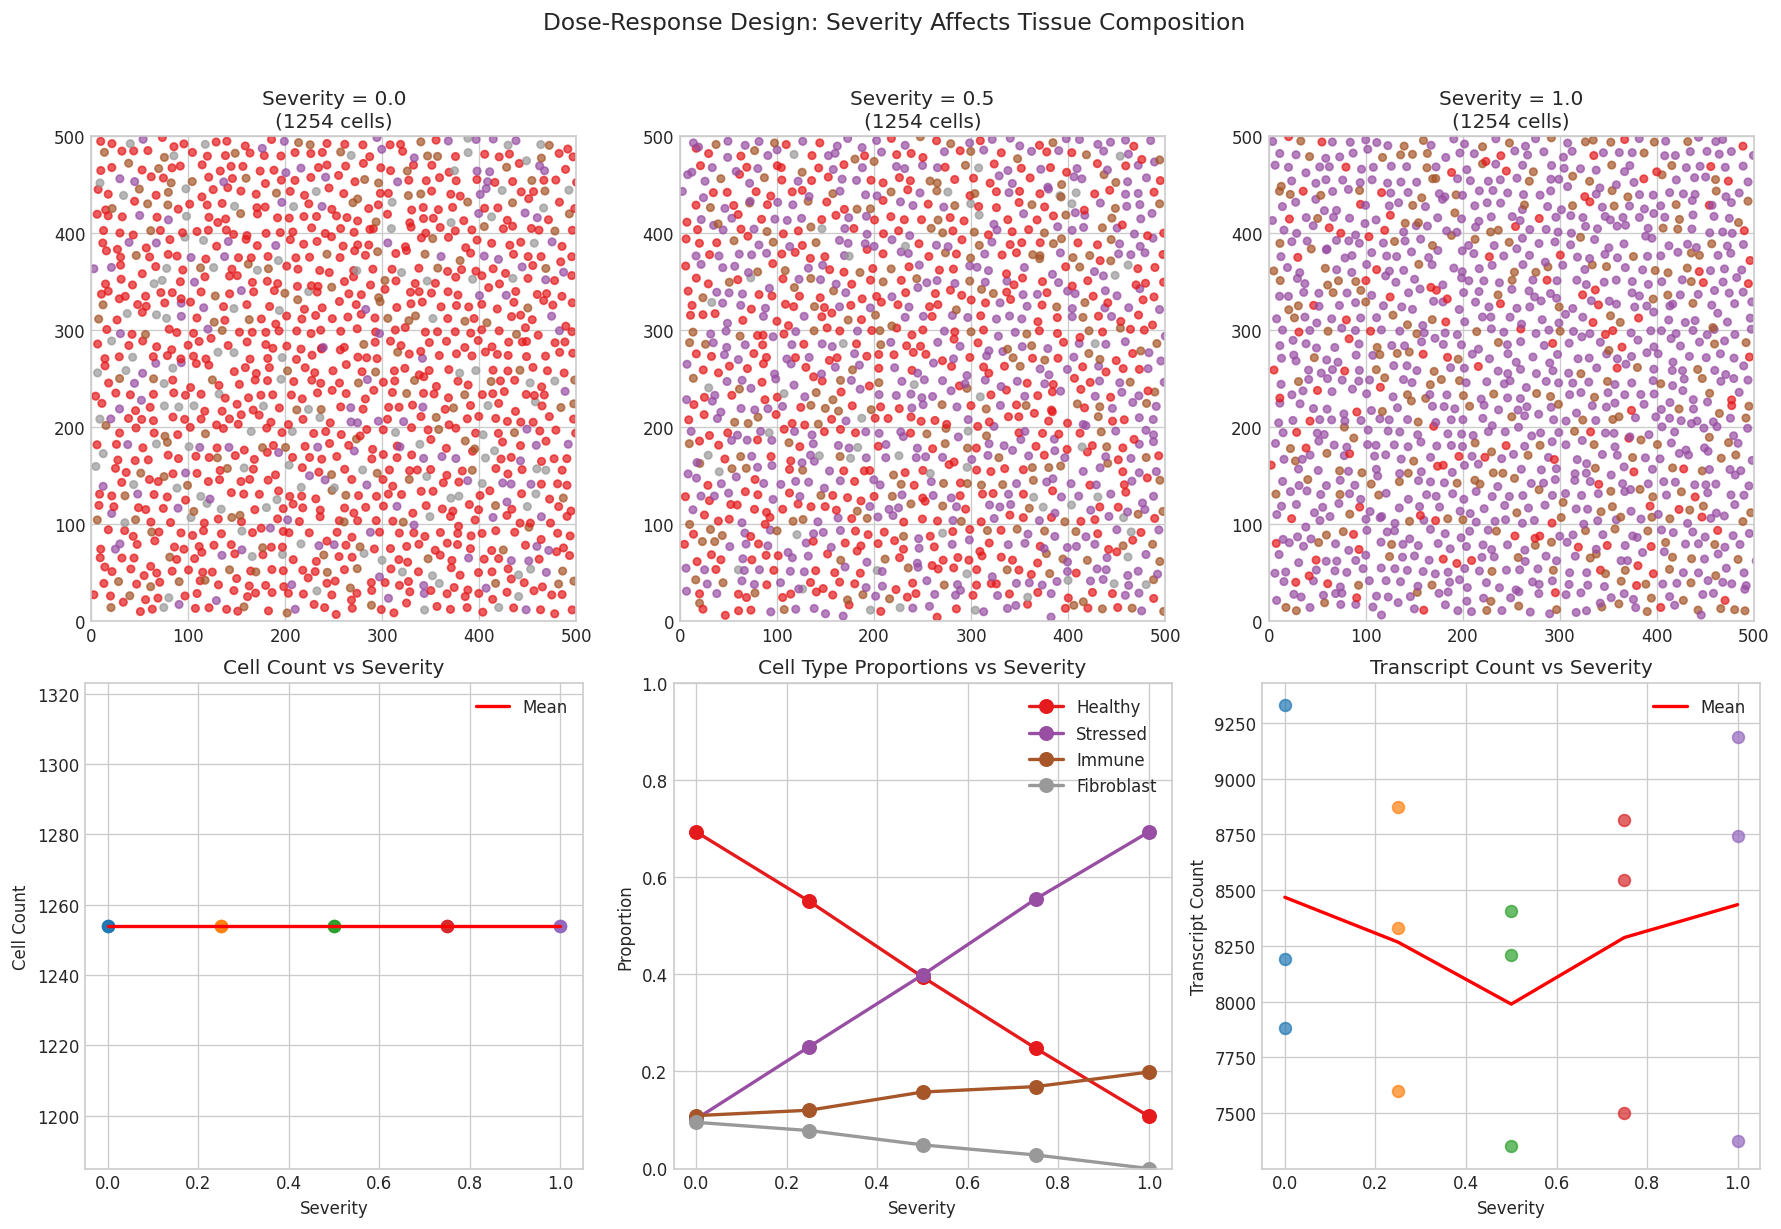

In [20]:
# Visualize the dose-response relationship
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Sample FOVs at different severity levels
severity_levels = [0.0, 0.5, 1.0]
for ax, sev in zip(axes[0], severity_levels):
    # Get first replicate at this severity
    fov_data = results_df[(results_df['severity'] == sev) & (results_df['replicate'] == 0)].iloc[0]
    fov = fov_data['fov']
    
    scatter = ax.scatter(fov.cell_centroids[:, 0], fov.cell_centroids[:, 1],
                         c=fov.class_instance, cmap='Set1', vmin=0, vmax=n_cell_types-1,
                         s=20, alpha=0.7)
    ax.set_xlim(0, frame_size)
    ax.set_ylim(0, frame_size)
    ax.set_aspect('equal')
    ax.set_title(f'Severity = {sev}\n({fov.n_cells} cells)')

# Row 2: Quantitative analysis
# Cell counts by severity
ax = axes[1, 0]
for sev in results_df['severity'].unique():
    data = results_df[results_df['severity'] == sev]
    ax.scatter([sev]*len(data), data['n_cells'], alpha=0.7, s=50)
means = results_df.groupby('severity')['n_cells'].mean()
ax.plot(means.index, means.values, 'r-', linewidth=2, label='Mean')
ax.set_xlabel('Severity')
ax.set_ylabel('Cell Count')
ax.set_title('Cell Count vs Severity')
ax.legend()

# Cell type proportions
ax = axes[1, 1]
type_names = ['Healthy', 'Stressed', 'Immune', 'Fibroblast']
colors = plt.cm.Set1(np.linspace(0, 1, n_cell_types))

for type_idx, (type_name, color) in enumerate(zip(type_names, colors)):
    props = []
    for sev in sorted(results_df['severity'].unique()):
        data = results_df[results_df['severity'] == sev]
        type_counts = [d['type_counts'].get(type_idx, 0) for d in data.to_dict('records')]
        total_counts = [d['n_cells'] for d in data.to_dict('records')]
        prop = np.mean([t/n if n > 0 else 0 for t, n in zip(type_counts, total_counts)])
        props.append(prop)
    ax.plot(sorted(results_df['severity'].unique()), props, '-o', 
            color=color, label=type_name, linewidth=2, markersize=8)

ax.set_xlabel('Severity')
ax.set_ylabel('Proportion')
ax.set_title('Cell Type Proportions vs Severity')
ax.legend()
ax.set_ylim(0, 1)

# Transcript counts
ax = axes[1, 2]
for sev in results_df['severity'].unique():
    data = results_df[results_df['severity'] == sev]
    ax.scatter([sev]*len(data), data['n_dots'], alpha=0.7, s=50)
means = results_df.groupby('severity')['n_dots'].mean()
ax.plot(means.index, means.values, 'r-', linewidth=2, label='Mean')
ax.set_xlabel('Severity')
ax.set_ylabel('Transcript Count')
ax.set_title('Transcript Count vs Severity')
ax.legend()

plt.suptitle('Dose-Response Design: Severity Affects Tissue Composition', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Design Matrix for Downstream Analysis

The `DesignMatrix` class tracks all covariate values and sample metadata.

In [21]:
# Summarize results
print("\nResults Summary:")
print(f"Total FOVs generated: {len(results_df)}")
print(f"\nSeverity levels: {sorted(results_df['severity'].unique())}")
print(f"Treatments: {sorted(results_df['treatment'].unique())}")
print(f"\nCells per FOV: min={results_df['n_cells'].min()}, max={results_df['n_cells'].max()}, mean={results_df['n_cells'].mean():.1f}")
print(f"Dots per FOV: min={results_df['n_dots'].min()}, max={results_df['n_dots'].max()}, mean={results_df['n_dots'].mean():.1f}")


Results Summary:
Total FOVs generated: 15

Severity levels: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]
Treatments: ['control']

Cells per FOV: min=1254, max=1254, mean=1254.0
Dots per FOV: min=7350, max=9328, mean=8288.7


In [22]:
# Export results for use in R or other tools
export_df = results_df[['condition_id', 'replicate', 'severity', 'treatment', 'n_cells', 'n_dots']].copy()

print("\nExportable data (first 10 rows):")
print(export_df.head(10))

# Save to CSV (optional)
# export_df.to_csv('simulation_results.csv', index=False)


Exportable data (first 10 rows):
   condition_id  replicate  severity treatment  n_cells  n_dots
0             0          0      0.00   control     1254    7882
1             0          1      0.00   control     1254    9328
2             0          2      0.00   control     1254    8192
3             1          0      0.25   control     1254    7598
4             1          1      0.25   control     1254    8871
5             1          2      0.25   control     1254    8330
6             2          0      0.50   control     1254    8207
7             2          1      0.50   control     1254    8408
8             2          2      0.50   control     1254    7350
9             3          0      0.75   control     1254    7501


In [23]:
# Filter samples by covariate values
high_severity = results_df[results_df['severity'] >= 0.75]
print(f"\nHigh severity samples (severity >= 0.75): {len(high_severity)}")
print(f"Average cells in high severity: {high_severity['n_cells'].mean():.1f}")

# Get unique conditions
unique_conditions = results_df[['severity', 'treatment']].drop_duplicates()
print(f"\nUnique conditions: {len(unique_conditions)}")
print(unique_conditions)


High severity samples (severity >= 0.75): 6
Average cells in high severity: 1254.0

Unique conditions: 5
    severity treatment
0       0.00   control
3       0.25   control
6       0.50   control
9       0.75   control
12      1.00   control


---
## 7. Complete Example: Multi-Factor Experiment

Let's run a complete experiment varying multiple factors.

In [24]:
# 3x3 factorial: Treatment × Severity
multi_design = SimulationDesign(
    name='full_factorial',
    covariate_system=cov_system,
    n_replicates=2,
)

# Generate conditions
conditions = multi_design.generate_conditions(
    mode='grid',
    severity=[0.0, 0.5, 1.0],
    treatment=['control', 'drug_A', 'drug_B'],
    cell_density=[1.0],
)

print(f"Multi-factor design: {multi_design.name}")
print(f"  Total FOVs: {len(conditions)}")

Multi-factor design: full_factorial
  Total FOVs: 18


In [25]:
# Modified generator that responds to treatment
def create_fov_generator_treatment(covariate_values):
    """
    Create FOV generator that responds to both severity and treatment.
    
    - Control: natural severity response
    - Drug A: reduces stressed cell proportion
    - Drug B: increases immune cell proportion
    """
    severity_val = covariate_values.get('severity', 0.0)
    treatment = covariate_values.get('treatment', 'control')
    
    # Base proportions from severity
    healthy_prop = max(0.1, 0.7 - 0.6 * severity_val)
    stressed_prop = min(0.7, 0.1 + 0.6 * severity_val)
    immune_prop = 0.1 + 0.1 * severity_val
    fibro_prop = 0.1
    
    # Apply treatment effects
    if treatment == 'drug_A':
        # Drug A reduces stressed cells, increases healthy
        reduction = 0.5 * stressed_prop
        stressed_prop -= reduction
        healthy_prop += reduction
    elif treatment == 'drug_B':
        # Drug B increases immune response
        immune_prop += 0.15
    
    # Normalize
    props = [healthy_prop, stressed_prop, immune_prop, fibro_prop]
    props = [max(0, p) for p in props]
    total = sum(props)
    props = [p / total for p in props]
    
    fov_dist = FOVDistribution(
        frame_size=frame_size,
        background_element=lambda: FrameWideElement(
            frame_size=frame_size,
            tipical_cell_spacing=15,
            rules=MixOfNCellTypesRule(
                n_cell_types=n_cell_types,
                list_N=list(range(n_cell_types)),
                proportions=props,
            ),
        ),
    )
    
    return fov_dist

# Run multi-factor experiment
from tqdm import tqdm

multi_results = []
multi_dm = multi_design.get_design_matrix()
multi_df_iter = multi_dm.to_dataframe()  # Convert to dataframe for iteration

for idx, row in tqdm(multi_df_iter.iterrows(), total=len(multi_df_iter), desc="Generating"):
    covariate_values = {
        'severity': row['severity'],
        'treatment': row['treatment'],
        'cell_density': row['cell_density'],
    }
    
    fov_dist = create_fov_generator_treatment(covariate_values)
    
    np.random.seed(int(row['condition_id'] * 1000 + row['replicate']))
    fov = fov_dist.generate_fov()
    
    multi_results.append({
        'severity': row['severity'],
        'treatment': row['treatment'],
        'replicate': row['replicate'],
        'n_cells': fov.n_cells,
        'healthy_prop': (fov.class_instance == 0).sum() / fov.n_cells if fov.n_cells > 0 else 0,
        'stressed_prop': (fov.class_instance == 1).sum() / fov.n_cells if fov.n_cells > 0 else 0,
        'immune_prop': (fov.class_instance == 2).sum() / fov.n_cells if fov.n_cells > 0 else 0,
        'fibro_prop': (fov.class_instance == 3).sum() / fov.n_cells if fov.n_cells > 0 else 0,
    })

multi_df = pd.DataFrame(multi_results)
print(f"\nCompleted: {len(multi_df)} FOVs")

Generating: 100%|██████████| 18/18 [00:00<00:00, 46.90it/s]


Completed: 18 FOVs


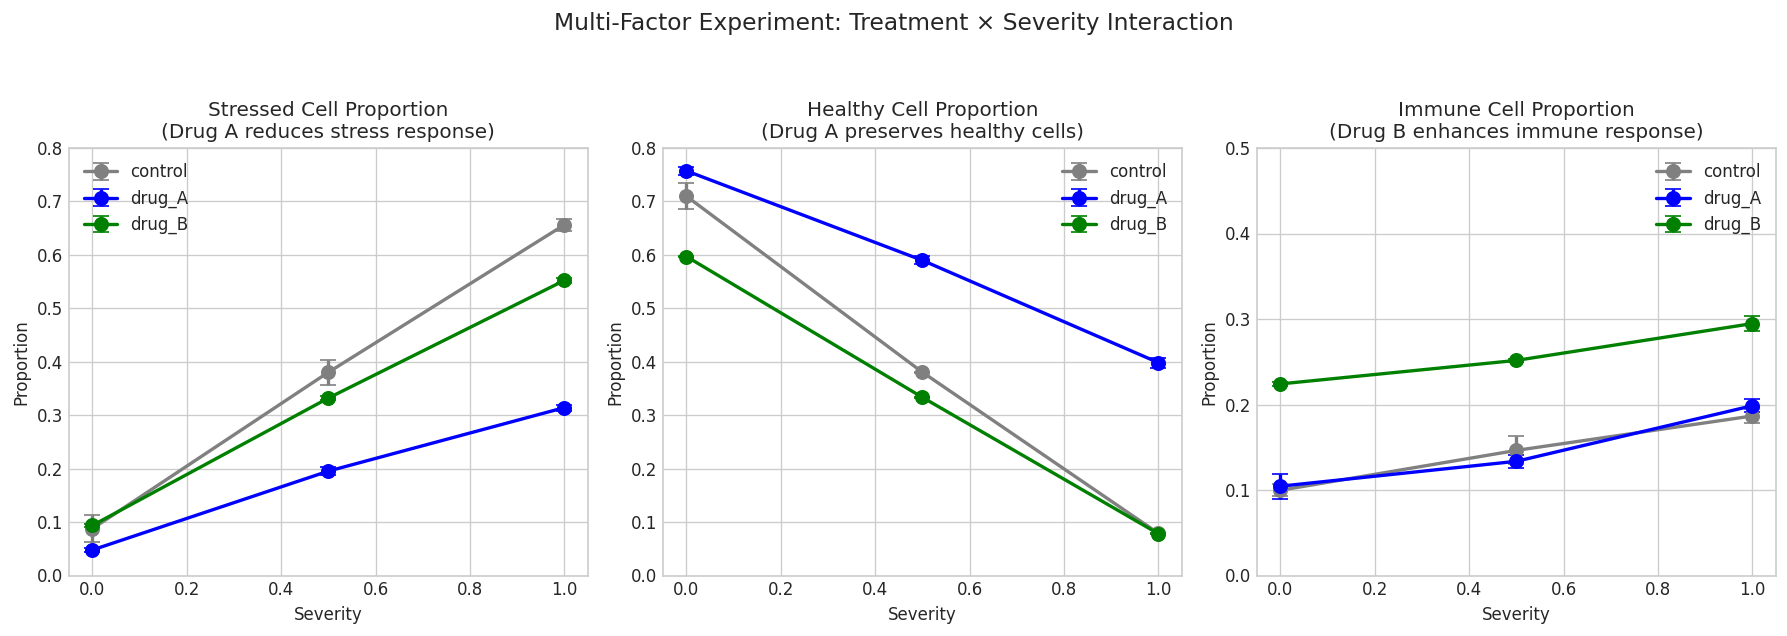

In [26]:
# Visualize treatment effects
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

treatments = ['control', 'drug_A', 'drug_B']
colors = {'control': 'gray', 'drug_A': 'blue', 'drug_B': 'green'}

# Stressed cells
ax = axes[0]
for treat in treatments:
    data = multi_df[multi_df['treatment'] == treat]
    means = data.groupby('severity')['stressed_prop'].mean()
    stds = data.groupby('severity')['stressed_prop'].std()
    ax.errorbar(means.index, means.values, yerr=stds.values, 
                fmt='-o', color=colors[treat], label=treat, 
                linewidth=2, markersize=8, capsize=5)
ax.set_xlabel('Severity')
ax.set_ylabel('Proportion')
ax.set_title('Stressed Cell Proportion\n(Drug A reduces stress response)')
ax.legend()
ax.set_ylim(0, 0.8)

# Healthy cells
ax = axes[1]
for treat in treatments:
    data = multi_df[multi_df['treatment'] == treat]
    means = data.groupby('severity')['healthy_prop'].mean()
    stds = data.groupby('severity')['healthy_prop'].std()
    ax.errorbar(means.index, means.values, yerr=stds.values,
                fmt='-o', color=colors[treat], label=treat,
                linewidth=2, markersize=8, capsize=5)
ax.set_xlabel('Severity')
ax.set_ylabel('Proportion')
ax.set_title('Healthy Cell Proportion\n(Drug A preserves healthy cells)')
ax.legend()
ax.set_ylim(0, 0.8)

# Immune cells
ax = axes[2]
for treat in treatments:
    data = multi_df[multi_df['treatment'] == treat]
    means = data.groupby('severity')['immune_prop'].mean()
    stds = data.groupby('severity')['immune_prop'].std()
    ax.errorbar(means.index, means.values, yerr=stds.values,
                fmt='-o', color=colors[treat], label=treat,
                linewidth=2, markersize=8, capsize=5)
ax.set_xlabel('Severity')
ax.set_ylabel('Proportion')
ax.set_title('Immune Cell Proportion\n(Drug B enhances immune response)')
ax.legend()
ax.set_ylim(0, 0.5)

plt.suptitle('Multi-Factor Experiment: Treatment × Severity Interaction', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

---
## Summary

This notebook covered PointillSim's design module for controlled experiments:

| Component | Purpose |
|-----------|--------|
| `Covariate` | Define continuous/categorical variables |
| `CovariateSystem` | Manage multiple covariates |
| `EffectController` | Toggle technical effects on/off |
| `SimulationDesign` | Specify experimental design |
| `DesignMatrix` | Track sample metadata |
| `CovariateBasedRule` | Cell types respond to covariates |

### Key Takeaways

1. **Covariates** let you systematically vary biological conditions
2. **Effect controllers** let you isolate specific sources of variation
3. **Factorial designs** enable studying interactions between factors
4. **Design matrices** facilitate downstream statistical analysis

### Next Steps

- **09_validation_and_difficulty.ipynb**: Assess simulation difficulty and validate results
- **10_advanced_structures.ipynb**: Explore advanced histological elements